# Homework 5: Neural Networks with Keras

**Name:** Christine Wu  
**Date:** Tuesday, May 19th

This notebook builds and evaluates neural networks on the census income dataset. The workflow reuses the census cleaning and feature engineering choices from the earlier in-class census notebooks. The target is binary income classification, where 1 means income is greater than 50K and 0 means income is less than or equal to 50K.


## 0. Import packages and set the random seed

This step loads the packages needed for data cleaning, encoding, scaling, neural network modeling, tuning, and evaluation. I set random seeds so that train/test splitting, model initialization, and tuning are easier to reproduce.


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import random
import warnings

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.get_logger().setLevel("ERROR")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 1. Load the census dataset

This step reads adult.csv. I use a short path search so the notebook can run when the file is in the same folder as the notebook, in /mnt/data, or in a local downloads folder. The dataset contains demographic, work, education, and capital variables used to predict whether income is above 50K.

In [2]:
possible_paths = [
    "adult.csv",
    "/mnt/data/adult.csv",
    "/Users/christinewu/Downloads/adult.csv"
]

adult_path = None
for path in possible_paths:
    if os.path.exists(path):
        adult_path = path
        break

if adult_path is None:
    raise FileNotFoundError("Could not find adult.csv. Put adult.csv in the same folder as this notebook.")

adult = pd.read_csv(adult_path)
print("Data path:", adult_path)
print("Shape:", adult.shape)
adult.head()

Data path: adult.csv
Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


## 2. Clean the target and standardize text values

This step follows the census in-class notebook cleaning logic. Question marks are converted to missing values, text columns are stripped of extra spaces, the target is mapped to 0 and 1, and gender is converted to 0 and 1. This keeps the target ready for binary cross entropy and keeps one useful binary feature in numeric form.

In [3]:
adult = adult.replace("?", np.nan)

for col in adult.select_dtypes(include="object").columns:
    adult[col] = adult[col].str.strip()

adult["income"] = adult["income"].map({"<=50K": 0, ">50K": 1})
adult["gender"] = adult["gender"].map({"Female": 0, "Male": 1})

print(adult["income"].value_counts(normalize=True).rename("target_rate"))
adult.head()

income
0    0.760718
1    0.239282
Name: target_rate, dtype: float64


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


## 3. Add engineered features from the census in-class notebook

This function reuses the engineered features that were useful in the earlier census work. The features include capital totals, log transformations, interactions, grouped categories, and binned variables. These features are included because the earlier census notebook treated capital behavior, age, education, work hours, marital status, occupation, and native country as meaningful predictors.

In [4]:
def add_features(df):
    df = df.copy()

    # Numeric transformations
    df["capital_total"] = df["capital-gain"] + df["capital-loss"]
    df["net_capital"] = df["capital-gain"] - df["capital-loss"]
    df["has_capital_gain"] = (df["capital-gain"] > 0).astype(int)
    df["has_capital_loss"] = (df["capital-loss"] > 0).astype(int)
    df["log_fnlwgt"] = np.log1p(df["fnlwgt"])
    df["log_capital_total"] = np.log1p(df["capital_total"])
    df["age_sq"] = df["age"] ** 2
    df["age_x_hours"] = df["age"] * df["hours-per-week"]
    df["education_x_age"] = df["educational-num"] * df["age"]
    df["capital_per_hour"] = df["capital_total"] / (df["hours-per-week"] + 1)

    # Grouped categories
    df["marital_group"] = np.where(
        df["marital-status"].isin(["Married-civ-spouse", "Married-AF-spouse"]),
        "Married",
        np.where(
            df["marital-status"].isin(["Divorced", "Separated", "Widowed"]),
            "Previously-married",
            "Not-married"
        )
    )

    white_collar = ["Exec-managerial", "Prof-specialty", "Tech-support", "Sales", "Adm-clerical"]
    blue_collar = ["Craft-repair", "Machine-op-inspct", "Transport-moving", "Handlers-cleaners", "Farming-fishing"]
    service = ["Other-service", "Priv-house-serv", "Protective-serv"]

    df["occupation_group"] = np.where(
        df["occupation"].isin(white_collar),
        "White-collar",
        np.where(
            df["occupation"].isin(blue_collar),
            "Blue-collar",
            np.where(df["occupation"].isin(service), "Service", "Other")
        )
    )

    df["country_group"] = np.where(df["native-country"] == "United-States", "US", "Non-US")

    # Bucketed features
    df["age_band"] = pd.cut(
        df["age"],
        bins=[0, 25, 35, 45, 55, 65, 100],
        labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
    )

    df["hours_band"] = pd.cut(
        df["hours-per-week"],
        bins=[0, 25, 40, 50, 60, 100],
        labels=["<=25", "26-40", "41-50", "51-60", "60+"]
    )

    return df

adult_fe = add_features(adult)

engineered_cols = [
    "capital_total", "net_capital", "has_capital_gain", "has_capital_loss",
    "log_fnlwgt", "log_capital_total", "age_sq", "age_x_hours",
    "education_x_age", "capital_per_hour", "marital_group",
    "occupation_group", "country_group", "age_band", "hours_band"
]

adult_fe[engineered_cols].head()

,capital_total,net_capital,has_capital_gain,has_capital_loss,log_fnlwgt,log_capital_total,age_sq,age_x_hours,education_x_age,capital_per_hour,marital_group,occupation_group,country_group,age_band,hours_band
0,0,0,0,0,12.331837,0.000000,625,1000,175,0.000000,Not-married,Blue-collar,US,<=25,26-40
1,0,0,0,0,11.405507,0.000000,1444,1900,342,0.000000,Married,Blue-collar,US,36-45,41-50
2,0,0,0,0,12.727696,0.000000,784,1120,336,0.000000,Married,Service,US,26-35,26-40
3,7688,7688,1,0,11.984952,8.947546,1936,1760,440,187.512195,Married,Blue-collar,US,36-45,26-40
4,0,0,0,0,11.547308,0.000000,324,540,180,0.000000,Not-married,Other,US,<=25,26-40


## 4. Split the data before encoding and scaling

This step creates a held-out test set before fitting encoders or scalers. The split is stratified so the income class balance is similar in training and test data. The test set is held out until final evaluation and model comparison.

In [5]:
X = adult_fe.drop(columns=["income"]).copy()
y = adult_fe["income"].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Training rows:", X_train_raw.shape[0])
print("Test rows:", X_test_raw.shape[0])
print("Training positive rate:", round(y_train.mean(), 4))
print("Test positive rate:", round(y_test.mean(), 4))

Training rows: 39073
Test rows: 9769
Training positive rate: 0.2393
Test positive rate: 0.2393


## 5. Encode categorical features and scale all inputs

Neural networks work best when inputs are numeric and on a comparable scale. This step fills missing values using training-set information, one-hot encodes categorical variables, aligns test columns to training columns, and fits the StandardScaler only on the training data to avoid test-set leakage.

In [6]:
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

# Fill missing values using training data only.
for col in numeric_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

for col in categorical_cols:
    X_train[col] = X_train[col].astype("object").fillna("Unknown")
    X_test[col] = X_test[col].astype("object").fillna("Unknown")

# One-hot encode and align columns.
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, dtype=int)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Scale after encoding so every input is on a comparable numeric scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Encoded training shape:", X_train_scaled.shape)
print("Encoded test shape:", X_test_scaled.shape)

Encoded training shape: (39073, 137)
Encoded test shape: (9769, 137)


## 6. Create helper functions for Keras models and evaluation

These helper functions keep the experiments fair and repeatable. The model builder uses a clear input layer, one or more dense hidden layers, and one sigmoid output unit for binary classification. The compile step uses binary cross entropy. The evaluation function reports threshold metrics and ROC AUC because the classes are imbalanced.


In [7]:
def build_binary_nn(
    input_dim,
    hidden_units=(16, 8),
    activation="relu",
    learning_rate=0.001,
    dropout_rate=0.0,
    l2_strength=0.0
):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs

    for units in hidden_units:
        regularizer = keras.regularizers.l2(l2_strength) if l2_strength > 0 else None
        x = layers.Dense(units, activation=activation, kernel_regularizer=regularizer)(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        loss=keras.losses.BinaryCrossentropy(),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model


def fit_model(model, epochs=30, batch_size=128, verbose=0):
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=verbose,
        shuffle=True
    )
    return history


def evaluate_model(model, X_eval, y_eval, label):
    y_prob = model.predict(X_eval, verbose=0).ravel()
    y_pred = (y_prob >= 0.50).astype(int)

    return {
        "model": label,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_prob)
    }


def plot_history(history, title):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["accuracy"], label="Training accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " accuracy")
    plt.legend()
    plt.show()

## 7. Model Configuration A: Baseline neural network

Configuration A is the baseline model. It uses a simple 16 to 8 funnel shape, ReLU hidden layers, a sigmoid output layer, Adam, and early stopping based on validation loss. This gives a starting point for all later comparisons.


In [8]:
tf.random.set_seed(SEED)

baseline_model = build_binary_nn(
    input_dim=X_train_scaled.shape[1],
    hidden_units=(16, 8),
    activation="relu",
    learning_rate=0.001,
    dropout_rate=0.0,
    l2_strength=0.0
)

baseline_history = fit_model(baseline_model, epochs=40, batch_size=128, verbose=0)

baseline_metrics = evaluate_model(
    baseline_model,
    X_test_scaled,
    y_test,
    "Configuration A: Baseline 16-8"
)
pd.DataFrame([baseline_metrics])


,model,accuracy,precision,recall,f1,roc_auc
0,Configuration A: Baseline 16-8,0.857201,0.728108,0.643713,0.683314,0.907704


## 8. Baseline training and validation behavior

These curves show whether the baseline is underfitting, overfitting, or still improving when training stops. I will use validation loss and validation accuracy to decide whether the next experiments should change capacity, regularization, or training setup.

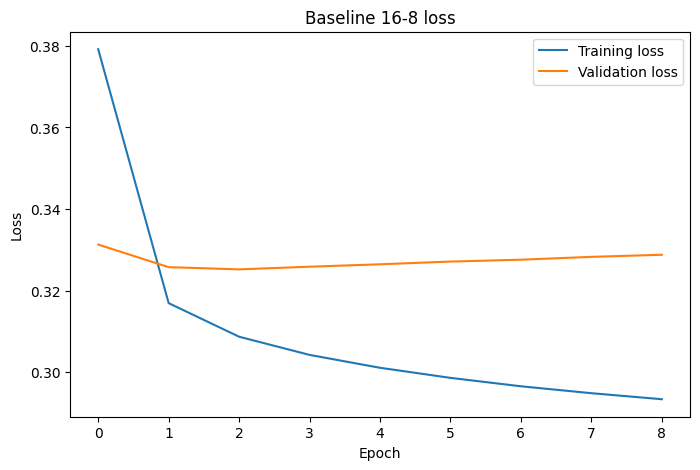

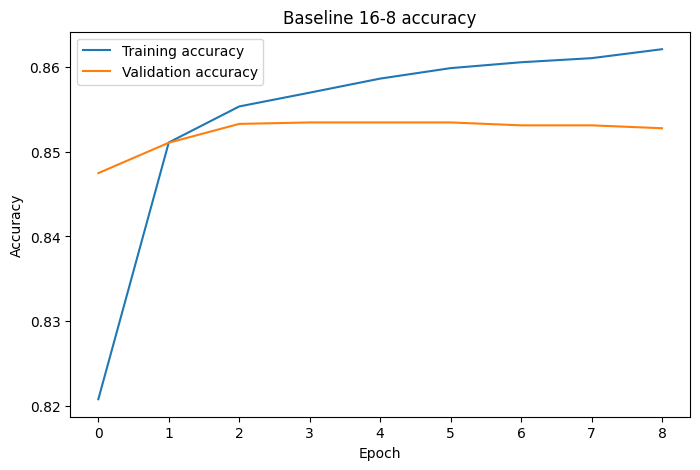

In [9]:
plot_history(baseline_history, "Baseline 16-8")

## 9. Experiment 1: Model capacity comparison

This experiment changes only the hidden layer sizes while keeping activation, optimizer, learning rate, batch size, validation split, and early stopping the same. This is a one-factor comparison of model capacity. The labeled configurations are B, C, and D, and the baseline shape is included again for reference.


In [10]:
capacity_configs = {
    "Configuration B: Small 8-4": (8, 4),
    "Configuration A: Baseline 16-8": (16, 8),
    "Configuration C: Medium 32-16": (32, 16),
    "Configuration D: Large 64-32": (64, 32)
}

capacity_results = []
capacity_histories = {}

for label, hidden_units in capacity_configs.items():
    tf.random.set_seed(SEED)
    model = build_binary_nn(
        input_dim=X_train_scaled.shape[1],
        hidden_units=hidden_units,
        activation="relu",
        learning_rate=0.001,
        dropout_rate=0.0,
        l2_strength=0.0
    )
    history = fit_model(model, epochs=40, batch_size=128, verbose=0)
    capacity_histories[label] = history
    capacity_results.append(evaluate_model(model, X_test_scaled, y_test, label))

capacity_results_df = pd.DataFrame(capacity_results).sort_values("roc_auc", ascending=False)
capacity_results_df


,model,accuracy,precision,recall,f1,roc_auc
1,Configuration A: Baseline 16-8,0.857201,0.738976,0.623610,0.676409,0.909691
0,Configuration B: Small 8-4,0.854335,0.715294,0.650128,0.681156,0.908393
2,Configuration C: Medium 32-16,0.856178,0.729916,0.633447,0.678269,0.908260
3,Configuration D: Large 64-32,0.855359,0.734891,0.618905,0.671929,0.907417


## 10. Capacity experiment curves

These plots compare whether larger models improve validation behavior or only improve training performance. If training accuracy rises while validation loss gets worse, the larger model is likely overfitting.

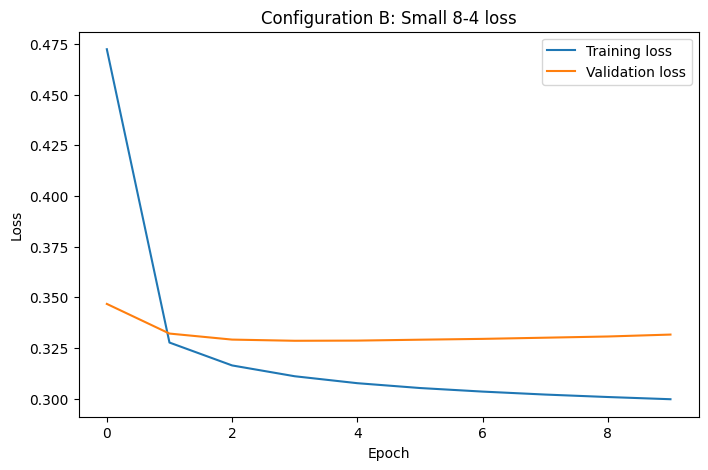

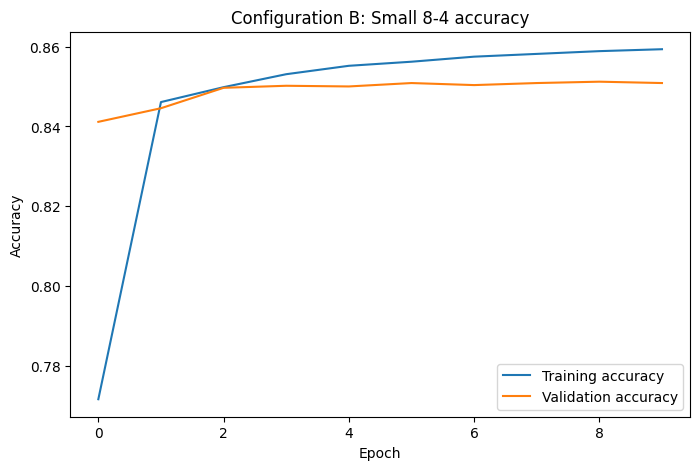

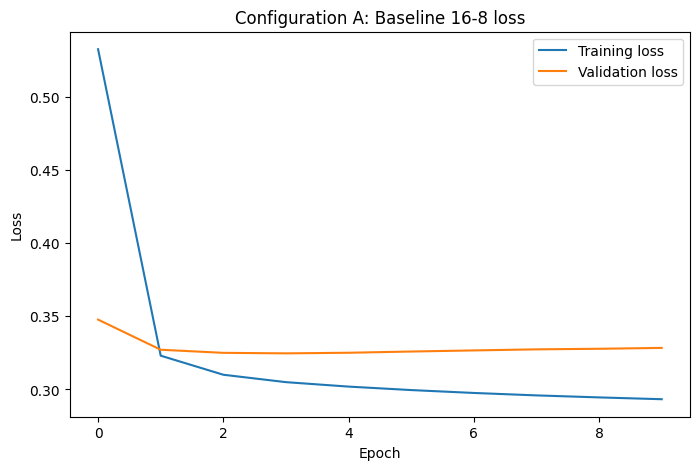

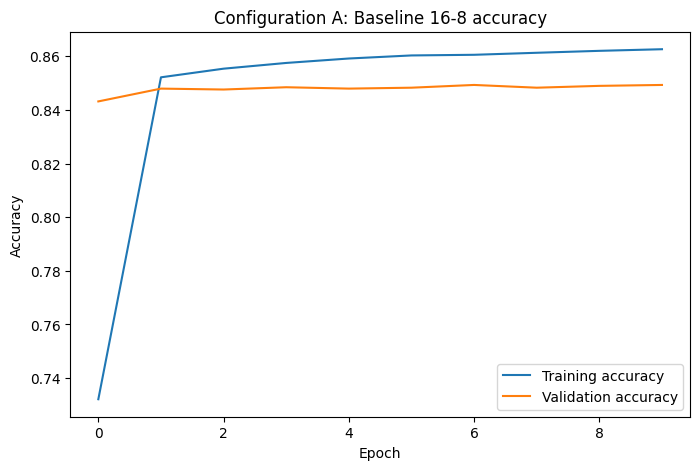

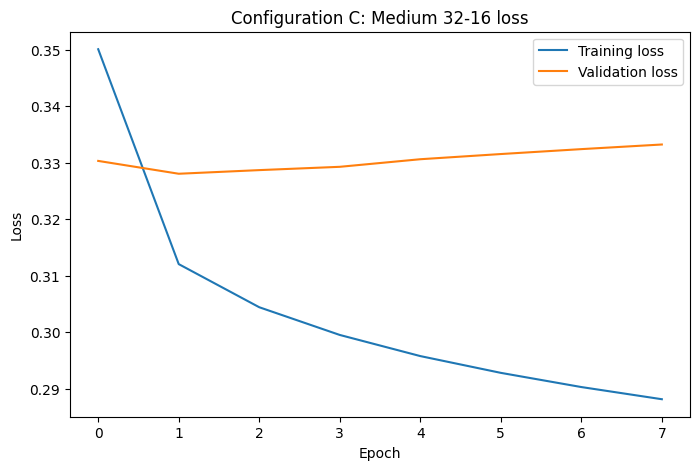

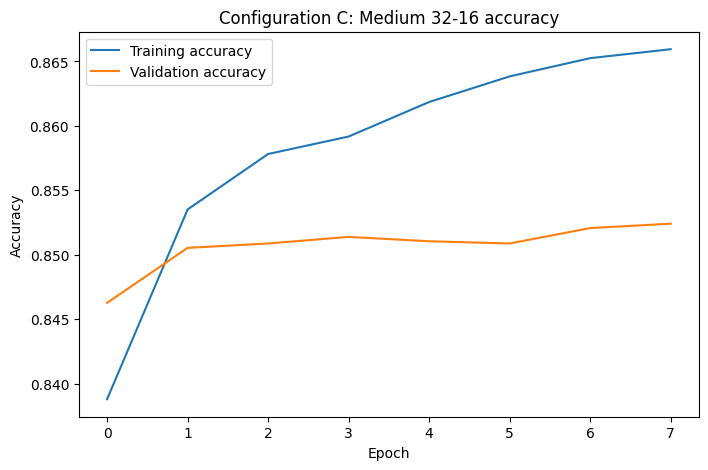

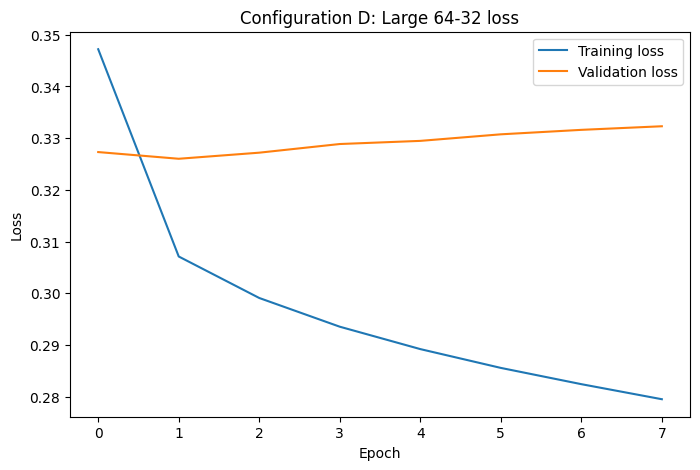

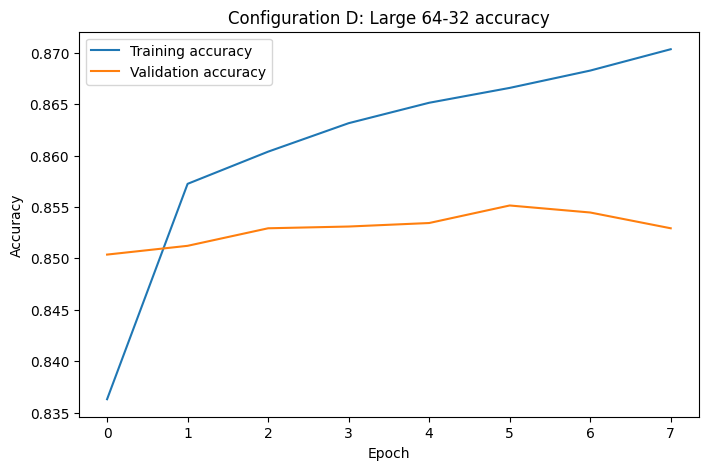

In [11]:
for label, history in capacity_histories.items():
    plot_history(history, label)

## 11. Experiment 2: Regularization comparison

This experiment keeps the selected architecture fixed and changes regularization. L2 penalizes large weights, while dropout randomly removes part of the hidden representation during training. The labeled configurations are E, F, G, and H.


In [13]:
best_capacity_label = capacity_results_df.iloc[0]["model"]
best_capacity_units = capacity_configs[best_capacity_label]
print("Best capacity setting:", best_capacity_label, best_capacity_units)

regularization_configs = {
    "Configuration E: No regularization": {"dropout_rate": 0.0, "l2_strength": 0.0},
    "Configuration F: Dropout 0.20": {"dropout_rate": 0.20, "l2_strength": 0.0},
    "Configuration G: L2 0.001": {"dropout_rate": 0.0, "l2_strength": 0.001},
    "Configuration H: Dropout 0.20 plus L2 0.001": {"dropout_rate": 0.20, "l2_strength": 0.001}
}

regularization_results = []
regularization_histories = {}

for label, params in regularization_configs.items():
    tf.random.set_seed(SEED)
    model = build_binary_nn(
        input_dim=X_train_scaled.shape[1],
        hidden_units=best_capacity_units,
        activation="relu",
        learning_rate=0.001,
        dropout_rate=params["dropout_rate"],
        l2_strength=params["l2_strength"]
    )
    history = fit_model(model, epochs=50, batch_size=128, verbose=0)
    regularization_histories[label] = history
    regularization_results.append(evaluate_model(model, X_test_scaled, y_test, label))

regularization_results_df = pd.DataFrame(regularization_results).sort_values("roc_auc", ascending=False)
regularization_results_df


Best capacity setting: Configuration A: Baseline 16-8 (16, 8)


,model,accuracy,precision,recall,f1,roc_auc
2,Configuration G: L2 0.001,0.860886,0.749109,0.629598,0.684174,0.911871
3,Configuration H: Dropout 0.20 plus L2 0.001,0.859351,0.737907,0.639435,0.685151,0.911809
0,Configuration E: No regularization,0.855564,0.734446,0.621044,0.673001,0.909140
1,Configuration F: Dropout 0.20,0.857508,0.736974,0.629170,0.678819,0.908552


## 12. Regularization experiment curves

These plots show whether dropout or L2 reduces the gap between training and validation performance. A stronger final model should improve validation performance or keep similar validation performance with less overfitting.

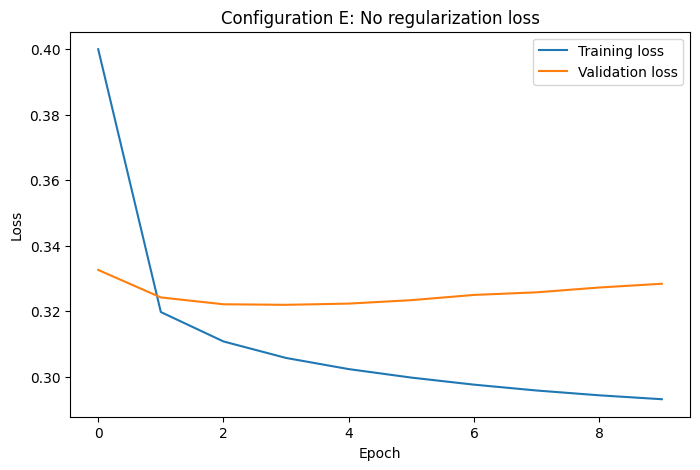

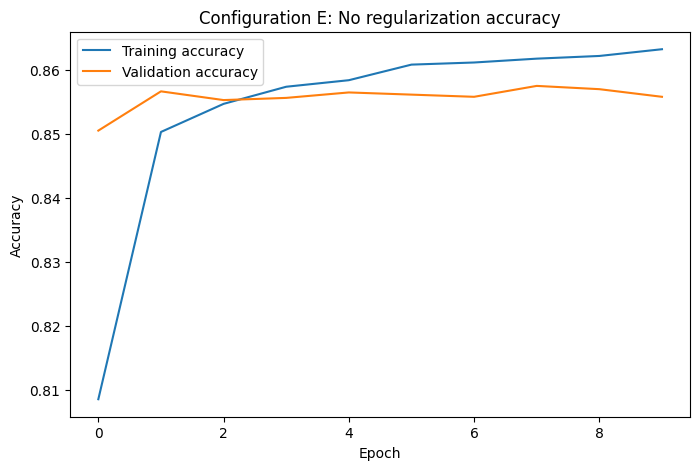

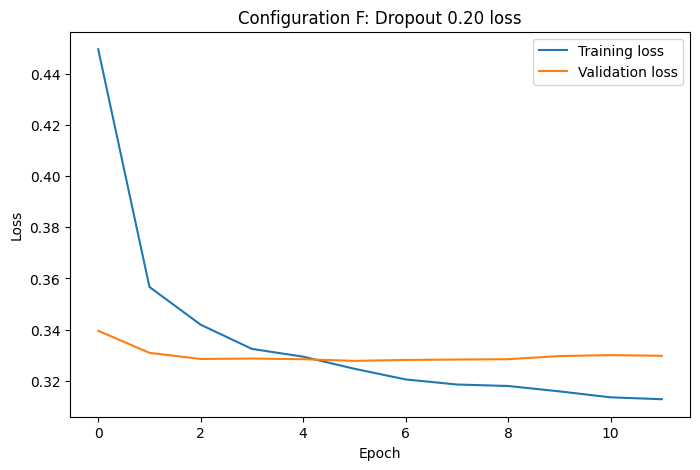

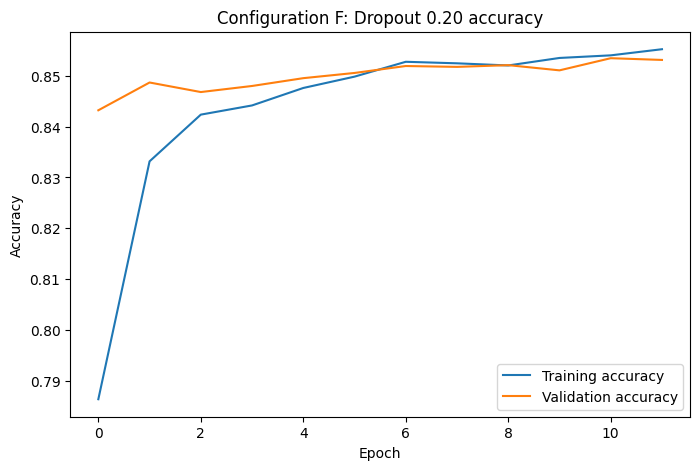

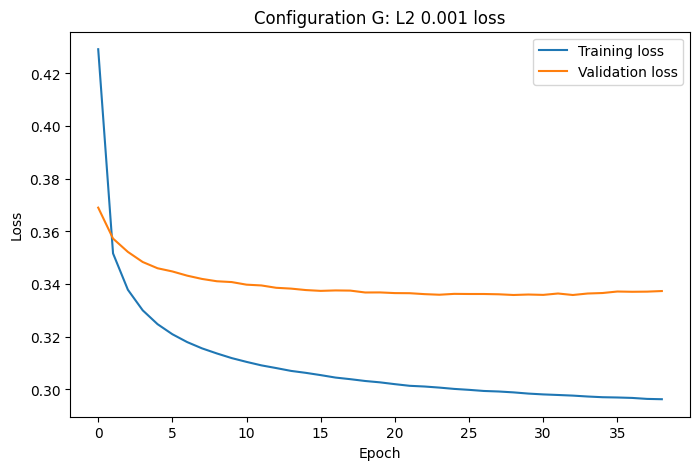

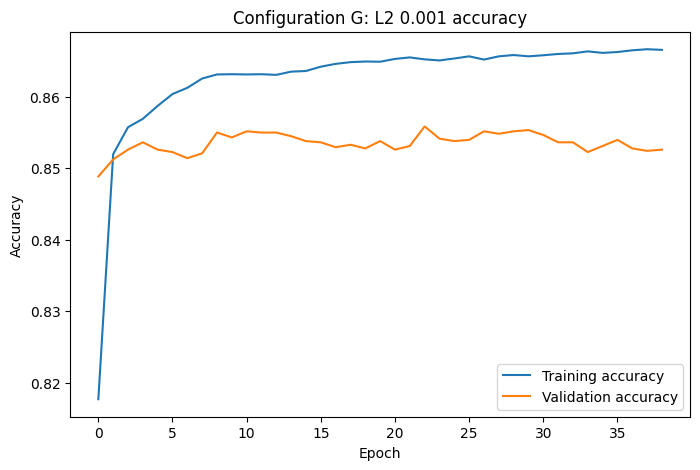

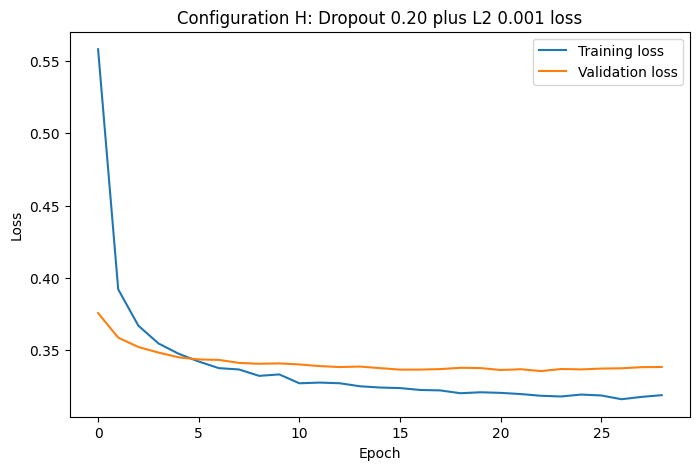

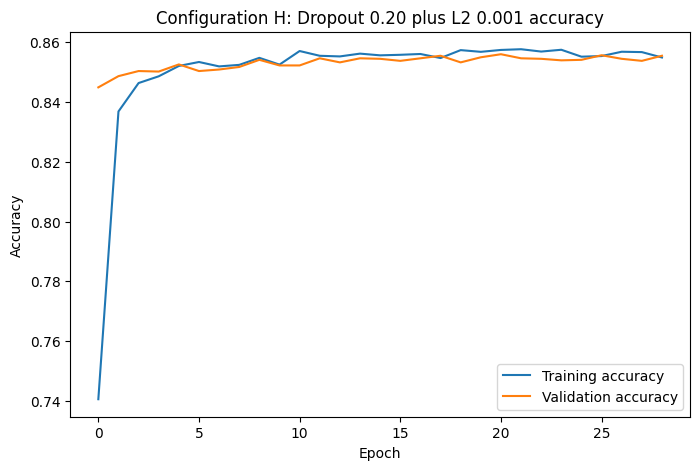

In [14]:
for label, history in regularization_histories.items():
    plot_history(history, label)

## 13. Experiment 3: Training setup comparison

This experiment keeps architecture and regularization fixed and changes batch size only. Batch size affects how often the optimizer updates the model weights. The labeled configurations are I, J, K, and L.


In [15]:
best_reg_label = regularization_results_df.iloc[0]["model"]
best_reg_params = regularization_configs[best_reg_label]
print("Best regularization setting:", best_reg_label, best_reg_params)

batch_size_configs = {
    "Configuration I: Batch size 32": 32,
    "Configuration J: Batch size 64": 64,
    "Configuration K: Batch size 128": 128,
    "Configuration L: Batch size 256": 256
}

training_results = []
training_histories = {}

for label, batch_size in batch_size_configs.items():
    tf.random.set_seed(SEED)
    model = build_binary_nn(
        input_dim=X_train_scaled.shape[1],
        hidden_units=best_capacity_units,
        activation="relu",
        learning_rate=0.001,
        dropout_rate=best_reg_params["dropout_rate"],
        l2_strength=best_reg_params["l2_strength"]
    )
    history = fit_model(model, epochs=50, batch_size=batch_size, verbose=0)
    training_histories[label] = history
    training_results.append(evaluate_model(model, X_test_scaled, y_test, label))

training_results_df = pd.DataFrame(training_results).sort_values("roc_auc", ascending=False)
training_results_df


Best regularization setting: Configuration G: L2 0.001 {'dropout_rate': 0.0, 'l2_strength': 0.001}


,model,accuracy,precision,recall,f1,roc_auc
1,Configuration J: Batch size 64,0.858327,0.744365,0.621471,0.677389,0.911729
3,Configuration L: Batch size 256,0.859863,0.748334,0.624465,0.680811,0.911630
2,Configuration K: Batch size 128,0.858737,0.746399,0.620616,0.677721,0.911256
0,Configuration I: Batch size 32,0.857304,0.752137,0.602224,0.668884,0.910267


## 14. Training setup curves

These plots show how batch size affects the smoothness and stability of the training and validation curves. I use the curves together with the test metrics to avoid choosing a model only because one score is slightly higher.

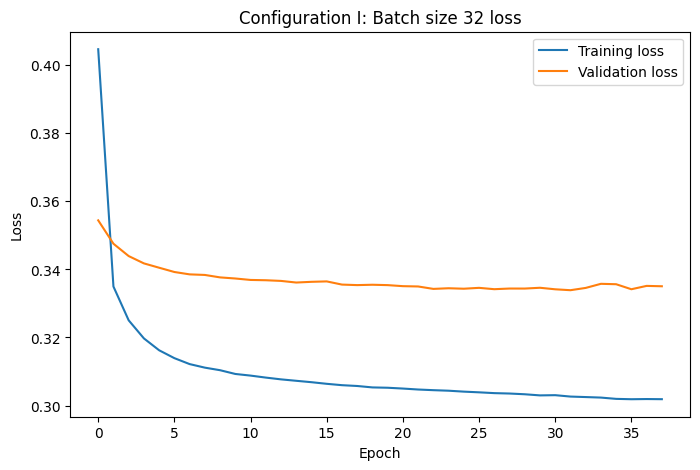

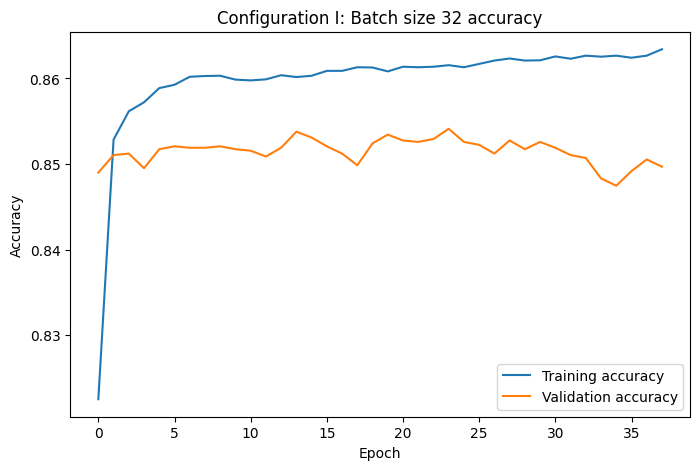

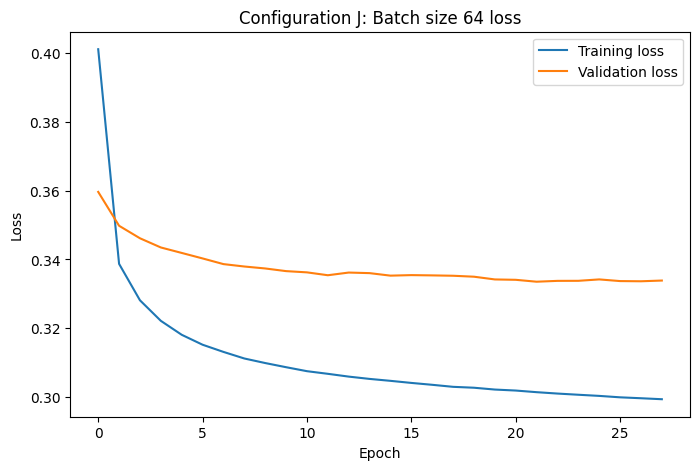

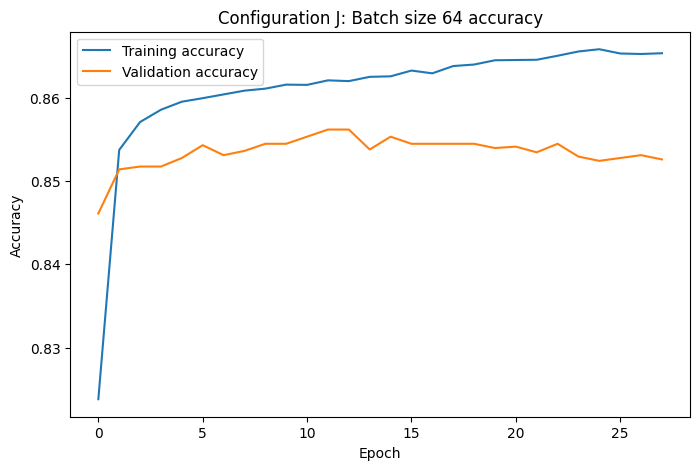

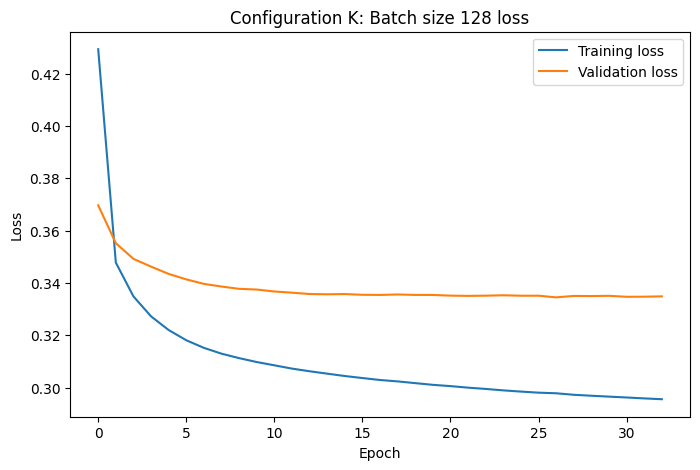

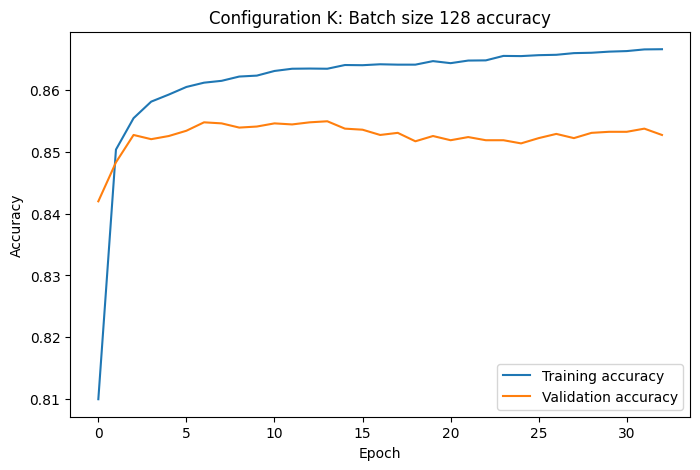

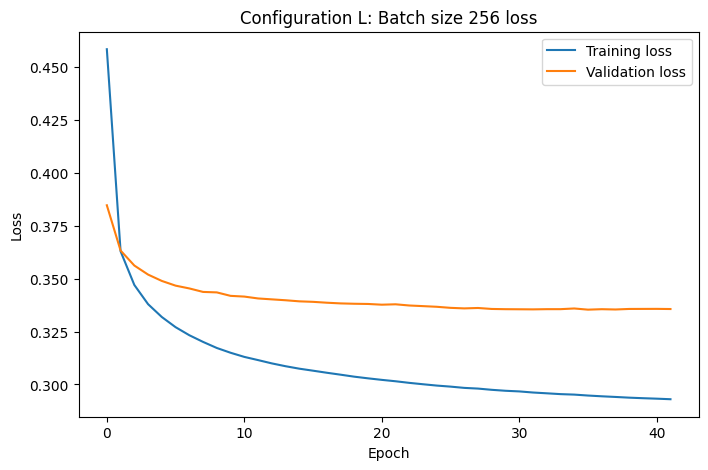

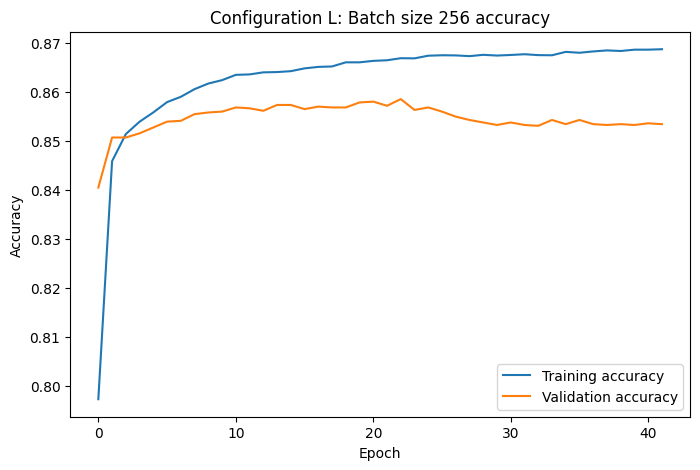

In [16]:
for label, history in training_histories.items():
    plot_history(history, label)

## 15. Systematic tuning with Optuna

This section uses Optuna to search model settings systematically. The search includes architecture, activation function, learning rate, dropout, L2, and batch size. The objective maximizes validation ROC AUC because ROC AUC evaluates probability ranking and is useful for an imbalanced binary outcome.


In [17]:
def optuna_objective(trial):
    tf.random.set_seed(SEED)

    n_layers = trial.suggest_int("n_layers", 1, 3)
    first_units = trial.suggest_categorical("first_units", [16, 32, 64])
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True)
    dropout_rate = trial.suggest_categorical("dropout_rate", [0.0, 0.1, 0.2, 0.3])
    l2_strength = trial.suggest_categorical("l2_strength", [0.0, 0.0001, 0.001])
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])

    if n_layers == 1:
        hidden_units = (first_units,)
    elif n_layers == 2:
        hidden_units = (first_units, max(first_units // 2, 8))
    else:
        hidden_units = (first_units, max(first_units // 2, 8), max(first_units // 4, 4))

    model = build_binary_nn(
        input_dim=X_train_scaled.shape[1],
        hidden_units=hidden_units,
        activation=activation,
        learning_rate=learning_rate,
        dropout_rate=dropout_rate,
        l2_strength=l2_strength
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.15,
        epochs=40,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0,
        shuffle=True
    )

    return max(history.history["val_auc"])

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(optuna_objective, n_trials=25, show_progress_bar=False)

print("Best validation ROC AUC:", study.best_value)
print("Best parameters:")
study.best_params


Best validation ROC AUC: 0.9090738892555237
Best parameters:


{'n_layers': 1,
 'first_units': 64,
 'activation': 'relu',
 'learning_rate': 0.0003656110561739652,
 'dropout_rate': 0.3,
 'l2_strength': 0.0001,
 'batch_size': 32}

## 16. Review tuning results

This table summarizes the Optuna trials. I sort by validation ROC AUC so the strongest configurations are easy to inspect before building the final model.

In [18]:
trials_df = study.trials_dataframe()
important_cols = [
    "number", "value", "params_n_layers", "params_first_units", "params_activation",
    "params_learning_rate", "params_dropout_rate", "params_l2_strength", "params_batch_size"
]
trials_df[important_cols].sort_values("value", ascending=False).head(10)

,number,value,params_n_layers,params_first_units,params_activation,params_learning_rate,params_dropout_rate,params_l2_strength,params_batch_size
22,22,0.909074,1,64,relu,0.000366,0.3,0.0001,32
24,24,0.908626,1,64,relu,0.000332,0.3,0.0001,32
21,21,0.908544,1,64,relu,0.000363,0.3,0.0001,32
20,20,0.908527,1,64,relu,0.000367,0.3,0.0001,32
19,19,0.908471,1,64,relu,0.000341,0.3,0.0001,32
6,6,0.908370,1,32,relu,0.001192,0.3,0.0010,256
23,23,0.908282,1,64,relu,0.000540,0.3,0.0001,32
7,7,0.908174,3,16,relu,0.000160,0.1,0.0010,32
14,14,0.907766,2,64,relu,0.000226,0.1,0.0010,32
4,4,0.907105,1,16,relu,0.000406,0.1,0.0010,128


## 17. Train the final tuned model

This step rebuilds the best Optuna model and trains it on the same training data with validation monitoring. The held-out test set is still not used during training. This gives a final training history and a final model for test evaluation.

In [19]:
best_params = study.best_params

if best_params["n_layers"] == 1:
    final_hidden_units = (best_params["first_units"],)
elif best_params["n_layers"] == 2:
    final_hidden_units = (best_params["first_units"], max(best_params["first_units"] // 2, 8))
else:
    final_hidden_units = (
        best_params["first_units"],
        max(best_params["first_units"] // 2, 8),
        max(best_params["first_units"] // 4, 4)
    )

tf.random.set_seed(SEED)
final_model = build_binary_nn(
    input_dim=X_train_scaled.shape[1],
    hidden_units=final_hidden_units,
    activation=best_params["activation"],
    learning_rate=best_params["learning_rate"],
    dropout_rate=best_params["dropout_rate"],
    l2_strength=best_params["l2_strength"]
)

final_history = fit_model(
    final_model,
    epochs=60,
    batch_size=best_params["batch_size"],
    verbose=0
)


## 18. Evaluate the final model on the held-out test set

This section evaluates the final tuned model on the test set that was held out before preprocessing. I report accuracy, precision, recall, F1, and ROC AUC. I also print the confusion matrix and classification report to check whether the model is missing too many high-income cases.

In [20]:
final_metrics = evaluate_model(final_model, X_test_scaled, y_test, "Configuration M: Final tuned model")
final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df


,model,accuracy,precision,recall,f1,roc_auc
0,Configuration M: Final tuned model,0.858942,0.743655,0.626604,0.68013,0.911552


## 19. Final confusion matrix, classification report, and ROC curve

These outputs show the final model behavior in more detail. The confusion matrix shows the error counts at a 0.50 threshold. The ROC curve evaluates ranking across possible thresholds, which is helpful when the preferred precision and recall balance might change by use case.

Confusion matrix:
[[6926  505]
 [ 873 1465]]

Classification report:
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.74      0.63      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.79      9769
weighted avg       0.85      0.86      0.85      9769



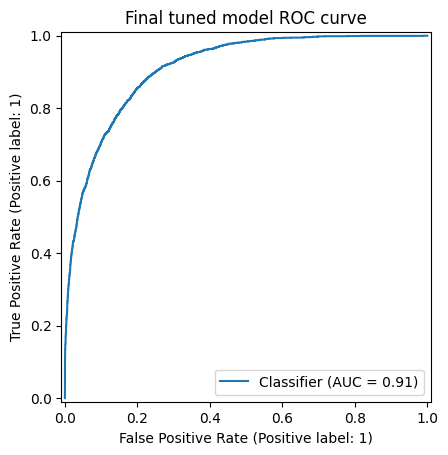

In [21]:
final_prob = final_model.predict(X_test_scaled, verbose=0).ravel()
final_pred = (final_prob >= 0.50).astype(int)

print("Confusion matrix:")
print(confusion_matrix(y_test, final_pred))
print()
print("Classification report:")
print(classification_report(y_test, final_pred, target_names=["<=50K", ">50K"]))

RocCurveDisplay.from_predictions(y_test, final_prob)
plt.title("Final tuned model ROC curve")
plt.show()

## 20. Final training and validation behavior

These curves support the final conclusion. A useful final model should have decreasing training and validation loss, stable validation accuracy, and no large persistent gap between training and validation performance.

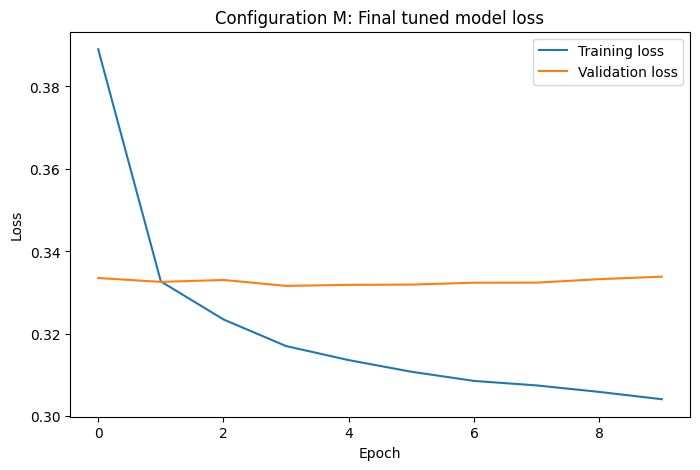

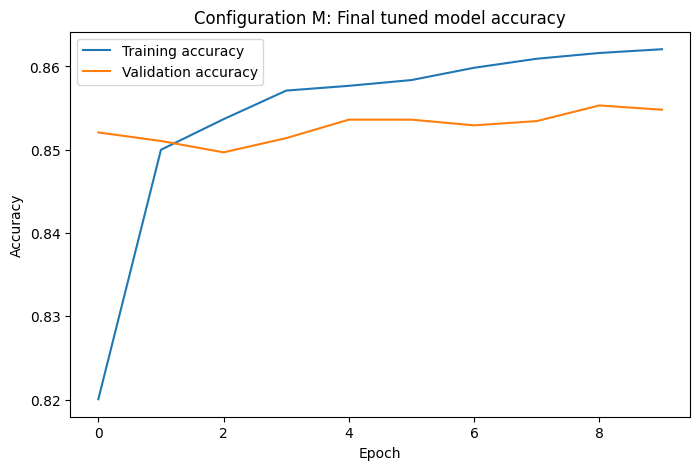

In [22]:
plot_history(final_history, "Configuration M: Final tuned model")


## 21. Compare all main model results

This table combines the baseline, experiment winners, and final tuned model. I use it to support the conclusion with both test-set metrics and training behavior rather than relying on one number.

In [23]:
summary_rows = []
summary_rows.append(baseline_metrics)
summary_rows.append(capacity_results_df.iloc[0].to_dict())
summary_rows.append(regularization_results_df.iloc[0].to_dict())
summary_rows.append(training_results_df.iloc[0].to_dict())
summary_rows.append(final_metrics)

summary_df = pd.DataFrame(summary_rows).drop_duplicates(subset=["model"])
summary_df.sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
2,Configuration G: L2 0.001,0.860886,0.749109,0.629598,0.684174,0.911871
3,Configuration J: Batch size 64,0.858327,0.744365,0.621471,0.677389,0.911729
4,Configuration M: Final tuned model,0.858942,0.743655,0.626604,0.680130,0.911552
0,Configuration A: Baseline 16-8,0.857201,0.728108,0.643713,0.683314,0.907704


## 22. Conclusions

The experiments showed that the neural network performance improved only slightly after increasing complexity, which suggests that the census dataset can already be modeled fairly well with a relatively simple architecture. The baseline model using the 16-8 funnel structure achieved 85.7% accuracy with an ROC AUC of 0.908. Increasing model capacity and testing different training setups produced small but measurable differences. The strongest experimental configuration before tuning was the L2 regularization model, which reached 86.1% accuracy and the highest ROC AUC at 0.912. The batch size experiment produced similar performance with 85.8% accuracy and an ROC AUC of 0.912, showing that training configuration changes had less impact than regularization. The final Optuna-tuned model achieved 85.9% accuracy, 0.744 precision, 0.627 recall, and 0.912 ROC AUC, which was competitive with the best manually tested configuration but did not dramatically outperform it.

The training and validation curves also supported the conclusion that the models were learning effectively without severe overfitting. Training loss consistently decreased while validation loss remained relatively stable across the strongest models. The final tuned model showed only a moderate gap between training and validation performance, which suggests that the regularization and early stopping settings were appropriate for this dataset. The confusion matrix and classification report showed that the model performed much better on the <=50K class than the >50K class, which is expected because the dataset is imbalanced. Precision for the higher-income class remained reasonably strong at 0.74, but recall stayed lower at around 0.63, meaning the model still missed a portion of positive cases. Overall, the results indicate that careful preprocessing, moderate network capacity, regularization, and systematic tuning were enough to produce stable and reliable performance without requiring an excessively deep architecture.

## 23. Personal workflow for future neural network projects

My future workflow for building neural networks will be:

1. Define the prediction problem and confirm the output layer and loss function match the target type.
2. Split the data first so the test set stays held out.
3. Clean missing values, encode categorical variables, and scale numeric inputs using training-set information only.
4. Start with a simple baseline model using one or two hidden layers.
5. Plot training and validation loss and accuracy before making changes.
6. Change one factor at a time for early experiments, such as capacity, regularization, learning rate, or batch size.
7. Use early stopping so the model does not continue training after validation performance stops improving.
8. Use a systematic tuning method after the manual experiments narrow the search space.
9. Evaluate the final model once on the held-out test set using multiple metrics.
10. Check whether the final model is actually better than a simpler model. The main pitfalls are data leakage, unscaled inputs, unfair comparisons, too many epochs, and choosing a model from test performance too early.